In [ ]:
#!/usr/bin/env python3
"""
Updated elevation-aware hourly IDW gridding for the MRoS project.

What this script does
---------------------
1. Interpolates continuous station predictors (temp_air, temp_dew, temp_wet, rh)
   using the existing dynamic lapse-rate detrend/retrend IDW workflow.
2. Interpolates categorical MRoS observations as one-hot class-support fields
   using elevation-aware 3-D IDW.
3. Saves full-grid MRoS predictor surfaces as p_snow / p_mix / p_rain.
4. Builds a pointwise leave-one-out (LOOCV) MRoS prediction table from the raw
   observation dataset so later ML rows can use leakage-safe MRoS predictors at
   raw MRoS locations.

Notes
-----
- Raw MRoS observations remain the labels for later ML.
- The MRoS gridded surfaces produced here are predictors only.
- The pointwise LOOCV output is the leakage-safe MRoS predictor product for ML.
"""

from __future__ import annotations

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # noqa: F401

import rasterio as rio
from rasterio.transform import rowcol as rio_rowcol
from rasterio.transform import xy as rio_xy
from rasterio.warp import calculate_default_transform, reproject, Resampling, transform_bounds

from pyproj import CRS, Transformer
from shapely.geometry import box
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from tqdm.auto import tqdm

# =============================================================================
# 0. Configuration
# =============================================================================
BASE_DIR = Path().resolve().parent
print("BASE_DIR:", BASE_DIR)

CONFIG = {
    "wy_start": "2024-10-01T00:00:00Z",
    "wy_end": "2025-05-31T23:59:59Z",
    "test_start": "2024-10-01T00:00:00Z",
    "test_end": "2025-05-31T23:59:59Z",
    "dem_path": BASE_DIR / "Data/elevation/DEM_1km_clipped.tif",
    "stations_parquet": BASE_DIR / "outputs/hourly_pipeline/hourly_data/stations_hourly.parquet",
    "mros_parquet": BASE_DIR / "outputs/hourly_pipeline/hourly_data/mros_hourly.parquet",
    "out_dir": BASE_DIR / "outputs/hourly_pipeline/IDW_refactored",
    "idw_power": 2.0,
    "k_nearest": 8,
    "min_points_global": 3,
    "min_points_lapse": 5,
    "lapse_degC_per_m": -0.005,
    "proj_fallback": "EPSG:26911",
    "mros_vertical_scale": 4.0,
    "eps": 1e-6,
}

VAR_CONFIG = {
    "temp_air": {"min_points": 4, "apply_lapse": True},
    "temp_dew": {"min_points": 4, "apply_lapse": True},
    "temp_wet": {"min_points": 4, "apply_lapse": True},
    "rh": {"min_points": 4, "apply_lapse": False},
    "mros_support_snow": {"min_points": 2, "apply_lapse": False},
    "mros_support_mix": {"min_points": 2, "apply_lapse": False},
    "mros_support_rain": {"min_points": 2, "apply_lapse": False},
}

OUT_DIR = Path(CONFIG["out_dir"])
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_NC = OUT_DIR / "hourly_predictors_1km_IDW.nc"
OUT_POINT_PARQUET = OUT_DIR / "mros_loocv_point_predictions_IDW.parquet"
OUT_POINT_CSV = OUT_DIR / "mros_loocv_point_predictions_IDW.csv"
OUT_SUMMARY_CSV = OUT_DIR / "mros_loocv_summary_IDW.csv"

MROS_PHASE_CANDIDATES = ["phase", "mros_phase", "phase_class", "ptype", "precip_phase", "phase_label"]
PHASE_ALIASES = {
    "snow": "snow", "s": "snow", "sn": "snow", "solid": "snow",
    "mix": "mix", "mixed": "mix", "transition": "mix", "m": "mix",
    "rain": "rain", "r": "rain", "liquid": "rain",
    "rain_snow": "mix", "snow_rain": "mix", "rainsnow": "mix",
}
SUPPORT_COLS = ["mros_support_snow", "mros_support_mix", "mros_support_rain"]
PHASES = ["snow", "mix", "rain"]

# =============================================================================
# 1. Time helpers
# =============================================================================
def to_utc(dt_series: pd.Series) -> pd.Series:
    return pd.to_datetime(dt_series, errors="coerce", utc=True).dt.floor("h")


def hourly_index(start_iso: str, end_iso: str) -> pd.DatetimeIndex:
    return pd.date_range(start=pd.to_datetime(start_iso), end=pd.to_datetime(end_iso), freq="h", tz="UTC")


# =============================================================================
# 2. DEM/grid utilities
# =============================================================================
def grid_centers(profile: dict) -> np.ndarray:
    T = profile["transform"]
    xs = T.c + (np.arange(profile["width"]) + 0.5) * T.a
    ys = T.f + (np.arange(profile["height"]) + 0.5) * T.e
    X, Y = np.meshgrid(xs, ys)
    return np.column_stack([X.ravel(), Y.ravel()])


def load_dem_reproject_if_needed(dem_path: Path, proj_fallback: str):
    with rio.open(dem_path) as src:
        dem_crs = src.crs
        if not dem_crs or not dem_crs.is_projected:
            dst_crs = proj_fallback
            transform, width, height = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
            kwargs = src.meta.copy()
            kwargs.update({"crs": dst_crs, "transform": transform, "width": width, "height": height})
            dem_reproj = np.empty((height, width), dtype=src.dtypes[0])
            reproject(
                source=rio.band(src, 1), destination=dem_reproj,
                src_transform=src.transform, src_crs=src.crs,
                dst_transform=transform, dst_crs=dst_crs,
                resampling=Resampling.bilinear,
            )
            profile = kwargs
            profile["count"] = 1
            return dem_reproj, profile, CRS.from_user_input(dst_crs)
        profile = src.profile.copy()
        dem = src.read(1)
        return dem, profile, CRS.from_user_input(src.crs)


def load_dem_and_aoi(dem_path: Path):
    with rio.open(dem_path) as src:
        bounds = src.bounds
        aoi_wgs84 = transform_bounds(src.crs, "EPSG:4326", bounds.left, bounds.bottom, bounds.right, bounds.top, densify_pts=21)
    return box(aoi_wgs84[0], aoi_wgs84[1], aoi_wgs84[2], aoi_wgs84[3])


def filter_points_to_aoi(df: pd.DataFrame, aoi_poly) -> pd.DataFrame:
    g = gpd.GeoDataFrame(df.copy(), geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs="EPSG:4326")
    mask = g.intersects(gpd.GeoSeries([aoi_poly], crs="EPSG:4326").iloc[0])
    return df.loc[mask.values].copy()


# =============================================================================
# 3. Projection / elevation helpers
# =============================================================================
def project_lonlat(df: pd.DataFrame, proj_crs) -> tuple[np.ndarray, np.ndarray]:
    tf = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
    x, y = tf.transform(df["lon"].values, df["lat"].values)
    return np.asarray(x, dtype=float), np.asarray(y, dtype=float)


def add_dem_elev_if_missing(df: pd.DataFrame, dem_data: np.ndarray, profile: dict, proj_crs) -> pd.DataFrame:
    out = df.copy()
    if "elev" not in out.columns:
        out["elev"] = np.nan
    need = out["elev"].isna()
    if not need.any():
        return out
    xx, yy = project_lonlat(out.loc[need, ["lon", "lat"]], proj_crs)
    rr, cc = rio_rowcol(profile["transform"], xx, yy, op=round)
    rr = np.clip(np.asarray(rr), 0, profile["height"] - 1)
    cc = np.clip(np.asarray(cc), 0, profile["width"] - 1)
    out.loc[need, "elev"] = dem_data[rr, cc]
    return out


# =============================================================================
# 4. Station lapse helpers
# =============================================================================
def estimate_lapse_rate(
    st_df: pd.DataFrame,
    temp_col: str = "temp_air",
    elev_col: str = "elev",
    default_lapse: float = -0.005,
    min_points: int = 5,
    bounds: tuple = (-0.009, 0.002),
) -> float:
    use = st_df.dropna(subset=[temp_col, elev_col])
    if len(use) < min_points:
        return default_lapse
    X = use[[elev_col]].values.astype(float)
    y = use[temp_col].values.astype(float)
    try:
        model = LinearRegression().fit(X, y)
        slope = float(model.coef_[0])
        return slope if bounds[0] <= slope <= bounds[1] else default_lapse
    except Exception:
        return default_lapse


# =============================================================================
# 5. IDW interpolation helpers
# =============================================================================
def idw_detrend_by_lapse(
    hour_points: pd.DataFrame,
    grid_xy: np.ndarray,
    grid_elev: np.ndarray,
    proj_crs,
    value_col: str,
    station_elev_col: str = "elev",
    lapse_degC_per_m: float = -0.005,
    idw_power: float = 2.0,
    k: int = 8,
    min_points: int = 3,
) -> np.ndarray:
    pts = hour_points.dropna(subset=[value_col, "lon", "lat", station_elev_col]).copy()
    if pts.empty or pts[value_col].notna().sum() < min_points:
        return np.full(grid_elev.shape, np.nan, dtype=np.float32)
    px, py = project_lonlat(pts, proj_crs)
    P = np.column_stack([px, py])
    vj = pts[value_col].to_numpy(dtype=float)
    zj = pts[station_elev_col].to_numpy(dtype=float)
    v_norm = vj - lapse_degC_per_m * zj
    tree = cKDTree(P)
    dists, idxs = tree.query(grid_xy, k=min(k, len(P)))
    if dists.ndim == 1:
        dists = dists[:, None]
        idxs = idxs[:, None]
    with np.errstate(divide="ignore"):
        w = 1.0 / np.power(dists, idw_power)
    w[np.isinf(w)] = 1e12
    w[~np.isfinite(w)] = 0.0
    w_sum = w.sum(axis=1, keepdims=True)
    w_norm = np.divide(w, w_sum, out=np.zeros_like(w), where=w_sum > 0)
    valid_counts = np.sum(w > 0, axis=1)
    v_interp_norm = np.sum(w_norm * v_norm[idxs], axis=1)
    v_interp_norm[valid_counts < min_points] = np.nan
    return (v_interp_norm + lapse_degC_per_m * grid_elev).astype(np.float32)


def _normalize_weights_from_distances(d_eff: np.ndarray, idw_power: float) -> np.ndarray:
    with np.errstate(divide="ignore"):
        w = 1.0 / np.power(d_eff, idw_power)
    w[np.isinf(w)] = 1e12
    w[~np.isfinite(w)] = 0.0
    w_sum = w.sum(axis=1, keepdims=True)
    return np.divide(w, w_sum, out=np.zeros_like(w), where=w_sum > 0)


def idw_3d_support(
    hour_points: pd.DataFrame,
    grid_xy: np.ndarray,
    grid_elev: np.ndarray,
    proj_crs,
    value_col: str,
    station_elev_col: str = "elev",
    idw_power: float = 2.0,
    k: int = 8,
    min_points: int = 2,
    z_scale: float = 4.0,
) -> np.ndarray:
    pts = hour_points.dropna(subset=[value_col, "lon", "lat", station_elev_col]).copy()
    if pts.empty or pts[value_col].notna().sum() < min_points:
        return np.full(grid_elev.shape, np.nan, dtype=np.float32)
    px, py = project_lonlat(pts, proj_crs)
    Pxy = np.column_stack([px, py])
    Pz = pts[station_elev_col].to_numpy(dtype=float)
    v = pts[value_col].to_numpy(dtype=float)
    tree = cKDTree(Pxy)
    d_xy, idxs = tree.query(grid_xy, k=min(k, len(Pxy)))
    if d_xy.ndim == 1:
        d_xy = d_xy[:, None]
        idxs = idxs[:, None]
    dz = grid_elev[:, None] - Pz[idxs]
    d_eff = np.sqrt(np.square(d_xy) + np.square(z_scale * dz))
    w_norm = _normalize_weights_from_distances(d_eff, idw_power)
    valid_counts = np.sum(np.isfinite(d_eff), axis=1)
    interp = np.sum(w_norm * v[idxs], axis=1)
    interp[valid_counts < min_points] = np.nan
    return interp.astype(np.float32)


def normalize_support_cube(snow: np.ndarray, mix: np.ndarray, rain: np.ndarray, eps: float):
    S = np.stack([np.clip(snow, 0.0, 1.0), np.clip(mix, 0.0, 1.0), np.clip(rain, 0.0, 1.0)], axis=0)
    total = np.nansum(S, axis=0)
    valid = total > eps
    out = np.full_like(S, np.nan, dtype=np.float32)
    out[:, valid] = (S[:, valid] / total[valid]).astype(np.float32)
    return out[0], out[1], out[2]


def interpolate_support_vector_at_point(
    train_df: pd.DataFrame,
    target_lon: float,
    target_lat: float,
    target_elev: float,
    proj_crs,
    support_cols: list[str],
    idw_power: float,
    k: int,
    min_points: int,
    z_scale: float,
    eps: float,
) -> dict[str, float]:
    train = train_df.dropna(subset=["lon", "lat", "elev"] + support_cols).copy()
    if len(train) < min_points:
        return {c: np.nan for c in support_cols}
    tx, ty = project_lonlat(pd.DataFrame({"lon": [target_lon], "lat": [target_lat]}), proj_crs)
    q_xy = np.column_stack([tx, ty])
    px, py = project_lonlat(train, proj_crs)
    Pxy = np.column_stack([px, py])
    Pz = train["elev"].to_numpy(dtype=float)
    tree = cKDTree(Pxy)
    d_xy, idxs = tree.query(q_xy, k=min(k, len(Pxy)))
    if np.ndim(d_xy) == 0:
        d_xy = np.array([[d_xy]], dtype=float)
        idxs = np.array([[idxs]], dtype=int)
    elif d_xy.ndim == 1:
        d_xy = d_xy[None, :]
        idxs = idxs[None, :]
    dz = target_elev - Pz[idxs]
    d_eff = np.sqrt(np.square(d_xy) + np.square(z_scale * dz))
    w = _normalize_weights_from_distances(d_eff, idw_power)[0]
    pred = {}
    for col in support_cols:
        vals = train[col].to_numpy(dtype=float)
        pred[col] = float(np.sum(w * vals[idxs[0]]))
    total = sum(max(pred[c], 0.0) for c in support_cols)
    if total <= eps:
        return {c: np.nan for c in support_cols}
    return {c: max(pred[c], 0.0) / total for c in support_cols}


# =============================================================================
# 6. MRoS preprocessing
# =============================================================================
def infer_phase_column(df: pd.DataFrame) -> str | None:
    for col in MROS_PHASE_CANDIDATES:
        if col in df.columns:
            return col
    return None


def canonicalize_phase_value(v) -> str | None:
    if pd.isna(v):
        return None
    s = str(v).strip().lower()
    return PHASE_ALIASES.get(s, s if s in PHASES else None)


def convert_legacy_proxy_to_phase(proxy: float) -> str | None:
    if pd.isna(proxy):
        return None
    if np.isclose(proxy, 0):
        return "snow"
    if np.isclose(proxy, 50):
        return "mix"
    if np.isclose(proxy, 100):
        return "rain"
    return None


def prepare_mros_onehot(mros_df: pd.DataFrame, dem_data, dem_profile, proj_crs) -> pd.DataFrame:
    df = mros_df.copy()
    phase_col = infer_phase_column(df)
    if phase_col is not None:
        df["mros_phase"] = df[phase_col].map(canonicalize_phase_value)
    elif "mros_plp_proxy" in df.columns:
        warnings.warn("No categorical phase column found; falling back to legacy mros_plp_proxy.")
        df["mros_phase"] = df["mros_plp_proxy"].map(convert_legacy_proxy_to_phase)
    else:
        raise ValueError("No categorical MRoS phase column found.")
    df = add_dem_elev_if_missing(df, dem_data=dem_data, profile=dem_profile, proj_crs=proj_crs)
    df["mros_support_snow"] = (df["mros_phase"] == "snow").astype(float)
    df["mros_support_mix"] = (df["mros_phase"] == "mix").astype(float)
    df["mros_support_rain"] = (df["mros_phase"] == "rain").astype(float)
    return df


def dedupe_station_hourly(df: pd.DataFrame, value_cols: list[str]) -> pd.DataFrame:
    grp = ["hour_utc", "lon", "lat"]
    def reducer(g: pd.DataFrame) -> pd.Series:
        out = {"hour_utc": g.name[0], "lon": g.name[1], "lat": g.name[2]}
        for c in value_cols:
            vals = pd.to_numeric(g[c], errors="coerce").dropna() if c in g.columns else pd.Series(dtype=float)
            out[c] = float(vals.mean()) if len(vals) else np.nan
        return pd.Series(out)
    return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)


def dedupe_mros_hourly(df: pd.DataFrame) -> pd.DataFrame:
    grp = ["hour_utc", "lon", "lat"]
    def reducer(g: pd.DataFrame) -> pd.Series:
        phases = g["mros_phase"].dropna().tolist()
        out = {"hour_utc": g.name[0], "lon": g.name[1], "lat": g.name[2]}
        if len(phases) == 0:
            out["mros_phase"] = None
            for c in SUPPORT_COLS:
                out[c] = np.nan
            return pd.Series(out)
        counts = pd.Series(phases).value_counts(normalize=True)
        out["mros_phase"] = counts.idxmax() if len(counts) == 1 else "soft_duplicate"
        out["mros_support_snow"] = float(counts.get("snow", 0.0))
        out["mros_support_mix"] = float(counts.get("mix", 0.0))
        out["mros_support_rain"] = float(counts.get("rain", 0.0))
        return pd.Series(out)
    return df.groupby(grp, dropna=False, sort=False).apply(reducer).reset_index(drop=True)


# =============================================================================
# 7. Pointwise LOOCV for leakage-safe MRoS predictors
# =============================================================================
def loocv_mros_hour(
    mros_t: pd.DataFrame,
    proj_crs,
    idw_power: float,
    k: int,
    min_points: int,
    z_scale: float,
    eps: float,
) -> tuple[pd.DataFrame, dict]:
    cols_needed = ["lon", "lat", "elev", "mros_phase"] + SUPPORT_COLS
    df = mros_t.dropna(subset=cols_needed).copy()
    if len(df) < max(min_points + 1, 3):
        return pd.DataFrame(), {
            "n_points": len(df), "n_eval": 0, "accuracy": np.nan,
            "macro_f1": np.nan, "multiclass_logloss": np.nan,
        }
    rows = []
    for i in range(len(df)):
        test = df.iloc[i]
        train = df.drop(df.index[i])
        pred = interpolate_support_vector_at_point(
            train_df=train,
            target_lon=float(test["lon"]),
            target_lat=float(test["lat"]),
            target_elev=float(test["elev"]),
            proj_crs=proj_crs,
            support_cols=SUPPORT_COLS,
            idw_power=idw_power,
            k=k,
            min_points=min_points,
            z_scale=z_scale,
            eps=eps,
        )
        if any(pd.isna(list(pred.values()))):
            continue
        probs = [pred["mros_support_snow"], pred["mros_support_mix"], pred["mros_support_rain"]]
        pred_phase = PHASES[int(np.argmax(probs))]
        rows.append({
            "lon": float(test["lon"]),
            "lat": float(test["lat"]),
            "elev": float(test["elev"]),
            "obs_phase": test["mros_phase"],
            "pred_phase": pred_phase,
            "mros_p_snow_loocv": pred["mros_support_snow"],
            "mros_p_mix_loocv": pred["mros_support_mix"],
            "mros_p_rain_loocv": pred["mros_support_rain"],
            "obs_p_snow": float(test["mros_support_snow"]),
            "obs_p_mix": float(test["mros_support_mix"]),
            "obs_p_rain": float(test["mros_support_rain"]),
            "pred_max_prob": float(np.max(probs)),
            "pred_entropy": float(-np.sum(np.clip(probs, eps, 1.0) * np.log(np.clip(probs, eps, 1.0)))),
            "pred_correct": int(pred_phase == test["mros_phase"]),
        })
    details = pd.DataFrame(rows)
    if details.empty:
        return details, {
            "n_points": len(df), "n_eval": 0, "accuracy": np.nan,
            "macro_f1": np.nan, "multiclass_logloss": np.nan,
        }
    y_true = details["obs_phase"].values
    y_pred = details["pred_phase"].values
    y_prob = details[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].values
    y_onehot = details[["obs_p_snow", "obs_p_mix", "obs_p_rain"]].values
    metrics = {
        "n_points": len(df),
        "n_eval": len(details),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, labels=PHASES, average="macro"),
    }
    try:
        metrics["multiclass_logloss"] = log_loss(y_onehot, y_prob)
    except Exception:
        metrics["multiclass_logloss"] = np.nan
    return details, metrics


def summarize_loocv(points_df: pd.DataFrame) -> pd.DataFrame:
    if points_df.empty:
        return pd.DataFrame([{
            "scope": "overall", "n_eval": 0, "accuracy": np.nan,
            "macro_f1": np.nan, "multiclass_logloss": np.nan,
        }])
    overall = {
        "scope": "overall",
        "n_eval": len(points_df),
        "accuracy": accuracy_score(points_df["obs_phase"], points_df["pred_phase"]),
        "macro_f1": f1_score(points_df["obs_phase"], points_df["pred_phase"], labels=PHASES, average="macro"),
    }
    try:
        overall["multiclass_logloss"] = log_loss(
            points_df[["obs_p_snow", "obs_p_mix", "obs_p_rain"]].values,
            points_df[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].values,
        )
    except Exception:
        overall["multiclass_logloss"] = np.nan

    by_hour = []
    for hour, g in points_df.groupby("hour_utc"):
        row = {"scope": "hourly", "hour_utc": hour, "n_eval": len(g)}
        row["accuracy"] = accuracy_score(g["obs_phase"], g["pred_phase"]) if len(g) else np.nan
        row["macro_f1"] = f1_score(g["obs_phase"], g["pred_phase"], labels=PHASES, average="macro") if len(g) else np.nan
        try:
            row["multiclass_logloss"] = log_loss(
                g[["obs_p_snow", "obs_p_mix", "obs_p_rain"]].values,
                g[["mros_p_snow_loocv", "mros_p_mix_loocv", "mros_p_rain_loocv"]].values,
            )
        except Exception:
            row["multiclass_logloss"] = np.nan
        by_hour.append(row)
    return pd.concat([pd.DataFrame([overall]), pd.DataFrame(by_hour)], ignore_index=True)


# =============================================================================
# 8. Main workflow
# =============================================================================
def main():
    print("\nLoading DEM...")
    dem1k_data, dem1k_profile, proj_crs = load_dem_reproject_if_needed(CONFIG["dem_path"], CONFIG["proj_fallback"])
    grid_xy = grid_centers(dem1k_profile)
    grid_elev = dem1k_data.ravel().astype(np.float32)

    hours = hourly_index(CONFIG["test_start"], CONFIG["test_end"])

    print("\nLoading hourly input datasets...")
    st_hr = pd.read_parquet(CONFIG["stations_parquet"])
    mros_hr = pd.read_parquet(CONFIG["mros_parquet"])
    st_hr["hour_utc"] = to_utc(st_hr["hour_utc"])
    mros_hr["hour_utc"] = to_utc(mros_hr["hour_utc"])

    aoi_poly = load_dem_and_aoi(CONFIG["dem_path"])
    st_hr = filter_points_to_aoi(st_hr, aoi_poly)
    mros_hr = filter_points_to_aoi(mros_hr, aoi_poly)

    available_station_vars = [c for c in ["temp_air", "temp_dew", "temp_wet", "rh"] if c in st_hr.columns]
    st_hr = st_hr[["hour_utc", "lon", "lat"] + available_station_vars].copy()
    st_hr = dedupe_station_hourly(st_hr, available_station_vars)
    st_hr = add_dem_elev_if_missing(st_hr, dem1k_data, dem1k_profile, proj_crs)

    mros_hr = prepare_mros_onehot(mros_hr, dem1k_data, dem1k_profile, proj_crs)
    mros_hr = mros_hr[["hour_utc", "lon", "lat", "elev", "mros_phase"] + SUPPORT_COLS].copy()
    mros_hr = dedupe_mros_hourly(mros_hr)
    mros_hr = add_dem_elev_if_missing(mros_hr, dem1k_data, dem1k_profile, proj_crs)

    H, W = dem1k_profile["height"], dem1k_profile["width"]
    T = dem1k_profile["transform"]
    rows = np.arange(H)
    cols = np.arange(W)
    x_centers = np.array([rio_xy(T, 0, c, offset="center")[0] for c in cols])
    y_centers = np.array([rio_xy(T, r, 0, offset="center")[1] for r in rows])
    coords = {"time": hours, "y": y_centers, "x": x_centers}

    variables = ["temp_air", "temp_dew", "temp_wet", "rh", "p_snow", "p_mix", "p_rain"]
    data_vars = {name: np.full((len(hours), H, W), np.nan, dtype=np.float32) for name in variables}
    loocv_point_rows = []

    print("\nStarting hourly interpolation...")
    for ti, t in enumerate(tqdm(hours, desc="Hourly surfaces", ncols=100)):
        st_t = st_hr[st_hr["hour_utc"] == t].copy()
        mros_t = mros_hr[mros_hr["hour_utc"] == t].copy()

        lapse_now = estimate_lapse_rate(
            st_t,
            temp_col="temp_air",
            elev_col="elev",
            default_lapse=CONFIG["lapse_degC_per_m"],
            min_points=CONFIG["min_points_lapse"],
        )

        for name in ["temp_air", "temp_dew", "temp_wet", "rh"]:
            if name not in st_t.columns:
                continue
            vcfg = VAR_CONFIG.get(name, {"min_points": CONFIG["min_points_global"], "apply_lapse": False})
            pts = st_t[["lon", "lat", "elev", name]].dropna(subset=[name]).copy()
            if pts[name].notna().sum() < vcfg["min_points"]:
                continue
            lapse_apply = lapse_now if vcfg.get("apply_lapse", False) else 0.0
            vals = idw_detrend_by_lapse(
                hour_points=pts,
                grid_xy=grid_xy,
                grid_elev=grid_elev,
                proj_crs=proj_crs,
                value_col=name,
                station_elev_col="elev",
                lapse_degC_per_m=lapse_apply,
                idw_power=CONFIG["idw_power"],
                k=CONFIG["k_nearest"],
                min_points=vcfg["min_points"],
            )
            data_vars[name][ti, :, :] = vals.reshape(H, W)

        if len(mros_t.dropna(subset=["lon", "lat", "elev", "mros_phase"])) >= 2:
            mros_surfaces = {}
            for support_col in SUPPORT_COLS:
                vcfg = VAR_CONFIG[support_col]
                vals = idw_3d_support(
                    hour_points=mros_t[["lon", "lat", "elev", support_col]].dropna(subset=[support_col]),
                    grid_xy=grid_xy,
                    grid_elev=grid_elev,
                    proj_crs=proj_crs,
                    value_col=support_col,
                    station_elev_col="elev",
                    idw_power=CONFIG["idw_power"],
                    k=CONFIG["k_nearest"],
                    min_points=vcfg["min_points"],
                    z_scale=CONFIG["mros_vertical_scale"],
                )
                mros_surfaces[support_col] = vals.reshape(H, W)
            snow_norm, mix_norm, rain_norm = normalize_support_cube(
                mros_surfaces["mros_support_snow"],
                mros_surfaces["mros_support_mix"],
                mros_surfaces["mros_support_rain"],
                eps=CONFIG["eps"],
            )
            data_vars["p_snow"][ti, :, :] = snow_norm
            data_vars["p_mix"][ti, :, :] = mix_norm
            data_vars["p_rain"][ti, :, :] = rain_norm

            cv_detail, _ = loocv_mros_hour(
                mros_t=mros_t,
                proj_crs=proj_crs,
                idw_power=CONFIG["idw_power"],
                k=CONFIG["k_nearest"],
                min_points=VAR_CONFIG["mros_support_snow"]["min_points"],
                z_scale=CONFIG["mros_vertical_scale"],
                eps=CONFIG["eps"],
            )
            if len(cv_detail):
                cv_detail = cv_detail.copy()
                cv_detail["hour_utc"] = t
                loocv_point_rows.append(cv_detail)

    ds = xr.Dataset(
        {**{k: xr.DataArray(v, coords=coords, dims=("time", "y", "x")) for k, v in data_vars.items()},
         "elev": xr.DataArray(dem1k_data.astype(np.float32), coords={"y": y_centers, "x": x_centers}, dims=("y", "x"))},
        attrs={
            "title": "Hourly predictor stacks on 1-km grid (IDW; MRoS probabilities)",
            "continuous_vars_elevation_method": "dynamic lapse detrend/retrend",
            "mros_elevation_method": "3D IDW distance metric with vertical scaling",
            "mros_vertical_scale": CONFIG["mros_vertical_scale"],
            "idw_power": CONFIG["idw_power"],
            "k_nearest": CONFIG["k_nearest"],
            "mros_note": "p_snow/p_mix/p_rain are predictor surfaces only; raw MRoS points remain labels.",
        },
    )
    if hasattr(ds.indexes["time"], "tz") and ds.indexes["time"].tz is not None:
        ds = ds.assign_coords(time=ds.indexes["time"].tz_localize(None))
    ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y", inplace=False)
    ds = ds.rio.write_crs(dem1k_profile["crs"])
    ds = ds.rio.write_transform(dem1k_profile["transform"])
    for v in ds.data_vars:
        ds[v].attrs.setdefault("grid_mapping", "spatial_ref")

    encoding = {name: {"zlib": True, "complevel": 4} for name in ds.data_vars}
    print(f"\nWriting NetCDF: {OUT_NC}")
    ds.to_netcdf(OUT_NC, engine="netcdf4", encoding=encoding)

    loocv_points = pd.concat(loocv_point_rows, ignore_index=True) if loocv_point_rows else pd.DataFrame()
    loocv_summary = summarize_loocv(loocv_points)
    if not loocv_points.empty:
        loocv_points.to_parquet(OUT_POINT_PARQUET, index=False)
        loocv_points.to_csv(OUT_POINT_CSV, index=False)
    loocv_summary.to_csv(OUT_SUMMARY_CSV, index=False)

    print("Wrote:")
    print(" -", OUT_NC)
    print(" -", OUT_POINT_PARQUET)
    print(" -", OUT_SUMMARY_CSV)
    return {"ds_interp": ds, "mros_loocv_points": loocv_points, "mros_loocv_summary": loocv_summary}


if __name__ == "__main__":
    main()


DATASET SUMMARY
<xarray.Dataset> Size: 6GB
Dimensions:      (time: 5832, y: 251, x: 142)
Coordinates:
  * y            (y) float64 2kB 4.426e+06 4.425e+06 ... 4.177e+06 4.176e+06
  * x            (x) float64 1kB 1.626e+05 1.636e+05 ... 3.026e+05 3.036e+05
  * time         (time) datetime64[ns] 47kB 2024-10-01 ... 2025-05-31T23:00:00
Data variables:
    temp_air     (time, y, x) float32 831MB ...
    temp_dew     (time, y, x) float32 831MB ...
    temp_wet     (time, y, x) float32 831MB ...
    rh           (time, y, x) float32 831MB ...
    p_snow       (time, y, x) float32 831MB ...
    p_mix        (time, y, x) float32 831MB ...
    p_rain       (time, y, x) float32 831MB ...
    elev         (y, x) float32 143kB ...
    spatial_ref  int64 8B ...
Attributes:
    title:                             Hourly predictor stacks on 1-km grid (...
    continuous_vars_elevation_method:  dynamic lapse detrend/retrend
    mros_elevation_method:             3D IDW distance metric with vertical s..

C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_66928\2583936748.py:218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_66928\2583936748.py:219: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_66928\2583936748.py:218: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_66928\2583936748.py:219: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

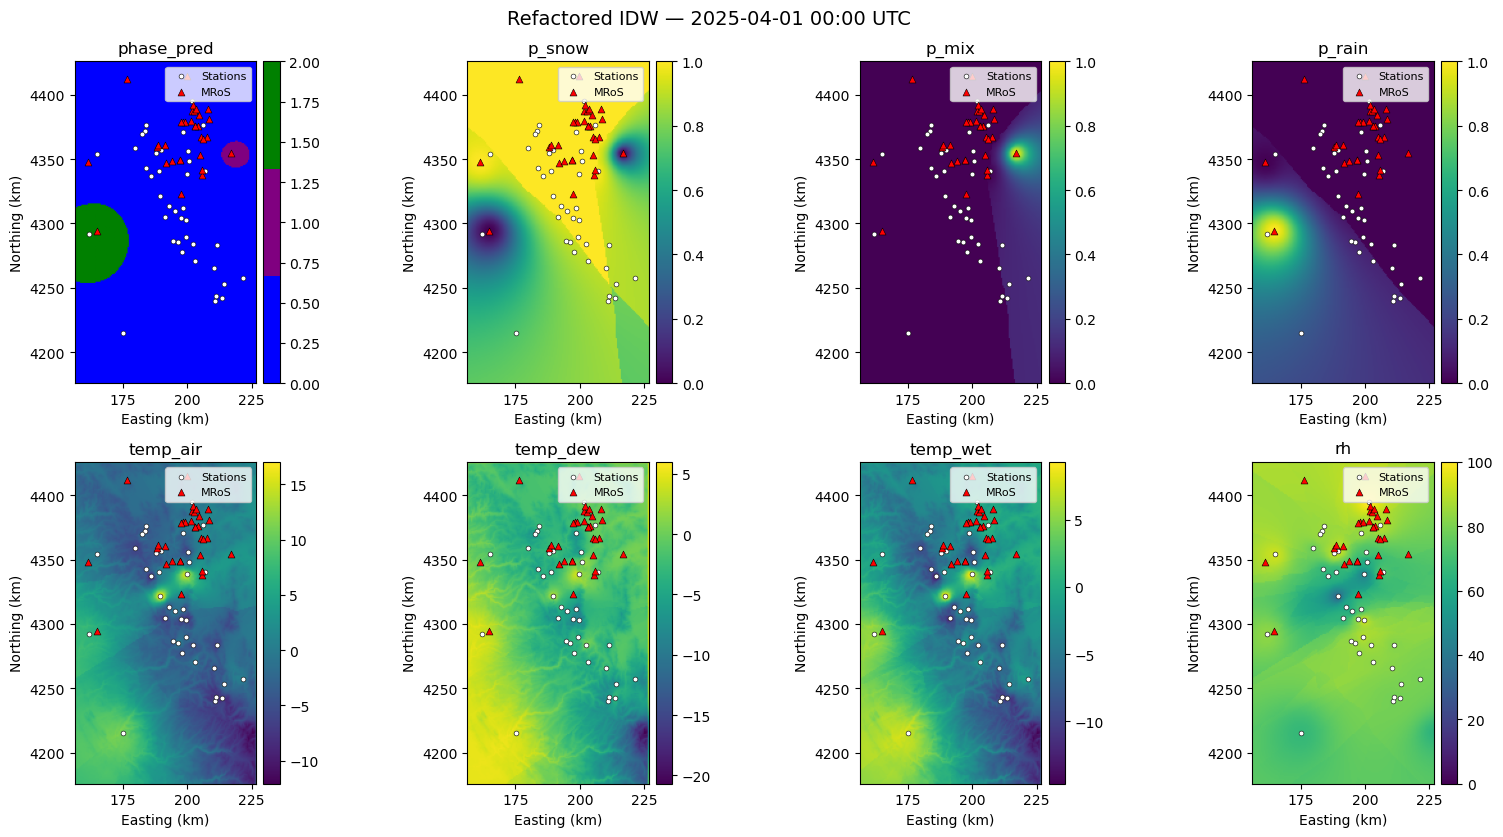


QUICK QC
temp_air   | finite=100.00% | min= -12.075 | max=  17.029 | mean=   0.382
temp_dew   | finite=100.00% | min= -20.686 | max=   5.983 | mean=  -1.690
temp_wet   | finite=100.00% | min= -14.653 | max=   9.302 | mean=  -1.980
rh         | finite=100.00% | min=  35.235 | max=  99.986 | mean=  78.155
p_snow     | finite=100.00% | min=   0.000 | max=   1.000 | mean=   0.830
p_mix      | finite=100.00% | min=   0.000 | max=   0.997 | mean=   0.034
p_rain     | finite=100.00% | min=   0.000 | max=   1.000 | mean=   0.136

Probability sum check at plotted timestep:
min  = 1.0000
max  = 1.0000
mean = 1.0000
std  = 0.0000

Quicklook complete.


In [4]:
# =============================================================================
# QUICKLOOK – REFACTORED IDW SUPPORT SURFACES (SINGLE DATE)
# =============================================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from pyproj import Transformer, CRS
from matplotlib.colors import ListedColormap


# ------------------------------------------------------------------
# FILE PATHS
# ------------------------------------------------------------------

IDW_PATH = Path(
    r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype"
    r"\outputs\hourly_pipeline\IDW_refactored"
    r"\hourly_predictors_1km_IDW.nc"
)

STATION_PATH = Path(
    r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype"
    r"\outputs\hourly_pipeline\hourly_data\stations_hourly.parquet"
)

MROS_PATH = Path(
    r"C:\Users\EmmaGolub\Desktop\MRoS_local\mros-precipitation-phase-product-prototype"
    r"\outputs\hourly_pipeline\hourly_data\mros_hourly.parquet"
)

TARGET_DATE = "2025-04-01"


# ------------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------------

ds = xr.open_dataset(IDW_PATH)
st_hr = pd.read_parquet(STATION_PATH)
mros_hr = pd.read_parquet(MROS_PATH)

print("=" * 80)
print("DATASET SUMMARY")
print("=" * 80)
print(ds)

print("\nVariables in dataset:")
print(list(ds.data_vars))


# ------------------------------------------------------------------
# FIND TIMESTAMP
# ------------------------------------------------------------------

times = pd.to_datetime(ds.time.values).floor("h")
mask = times.normalize() == pd.to_datetime(TARGET_DATE)

if not mask.any():
    raise ValueError(f"No timestep found for {TARGET_DATE}")

ti = np.where(mask)[0][0]
t_plot = times[ti]

print("\nPlotting timestep:", t_plot)


# ------------------------------------------------------------------
# GRID EXTENT
# ------------------------------------------------------------------

xmin, xmax = ds.x.min().item(), ds.x.max().item()
ymin, ymax = ds.y.min().item(), ds.y.max().item()
extent = [xmin, xmax, ymin, ymax]


# ------------------------------------------------------------------
# RESOLVE CRS
# ------------------------------------------------------------------

if "spatial_ref" in ds and "crs_wkt" in ds["spatial_ref"].attrs:
    ds_crs = ds["spatial_ref"].attrs["crs_wkt"]
elif "crs" in ds.attrs:
    ds_crs = ds.attrs["crs"]
else:
    raise ValueError("No CRS information found in dataset (neither spatial_ref nor global crs attr).")

tf = Transformer.from_crs("EPSG:4326", CRS.from_user_input(ds_crs), always_xy=True)


# ------------------------------------------------------------------
# FILTER OBS TO MATCHING HOUR
# ------------------------------------------------------------------

if st_hr["hour_utc"].dt.tz is not None:
    st_time = st_hr["hour_utc"].dt.tz_convert(None)
else:
    st_time = st_hr["hour_utc"]

if mros_hr["hour_utc"].dt.tz is not None:
    mros_time = mros_hr["hour_utc"].dt.tz_convert(None)
else:
    mros_time = mros_hr["hour_utc"]

st_t = st_hr[st_time.dt.floor("h") == t_plot].copy()
mros_t = mros_hr[mros_time.dt.floor("h") == t_plot].copy()


# ------------------------------------------------------------------
# PROJECT OBSERVATIONS
# ------------------------------------------------------------------

st_x, st_y = np.array([]), np.array([])
if len(st_t):
    sx, sy = tf.transform(st_t["lon"].values, st_t["lat"].values)
    sx, sy = np.asarray(sx), np.asarray(sy)
    st_mask = (sx >= xmin) & (sx <= xmax) & (sy >= ymin) & (sy <= ymax)
    st_x, st_y = sx[st_mask], sy[st_mask]

mo_x, mo_y = np.array([]), np.array([])
if len(mros_t):
    mx, my = tf.transform(mros_t["lon"].values, mros_t["lat"].values)
    mx, my = np.asarray(mx), np.asarray(my)
    mo_mask = (mx >= xmin) & (mx <= xmax) & (my >= ymin) & (my <= ymax)
    mo_x, mo_y = mx[mo_mask], my[mo_mask]

print(f"Stations in grid: {len(st_x)}")
print(f"MRoS in grid:     {len(mo_x)}")


# ------------------------------------------------------------------
# BUILD PHASE MAP FROM p_snow / p_mix / p_rain
# ------------------------------------------------------------------

p_snow = ds["p_snow"].isel(time=ti).values
p_mix  = ds["p_mix"].isel(time=ti).values
p_rain = ds["p_rain"].isel(time=ti).values

phase_pred = np.argmax(np.stack([p_snow, p_mix, p_rain]), axis=0)

phase_cmap = ListedColormap(["blue", "purple", "green"])  # snow, mix, rain


# ------------------------------------------------------------------
# VARIABLES TO PLOT
# ------------------------------------------------------------------

vars_to_plot = [
    ("phase_pred", phase_pred),
    ("p_snow", p_snow),
    ("p_mix", p_mix),
    ("p_rain", p_rain),
    ("temp_air", ds["temp_air"].isel(time=ti).values),
    ("temp_dew", ds["temp_dew"].isel(time=ti).values),
    ("temp_wet", ds["temp_wet"].isel(time=ti).values),
    ("rh", ds["rh"].isel(time=ti).values),
]


# ------------------------------------------------------------------
# PLOT
# ------------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
axes = axes.flatten()

fig.suptitle(f"Refactored IDW — {t_plot:%Y-%m-%d %H:%M UTC}", fontsize=14)

for i, (name, arr) in enumerate(vars_to_plot):
    ax = axes[i]

    if name == "phase_pred":
        im = ax.imshow(
            arr,
            origin="upper",
            extent=extent,
            cmap=phase_cmap,
            vmin=0,
            vmax=2,
            aspect="equal"
        )

    elif name in ("p_snow", "p_mix", "p_rain"):
        im = ax.imshow(
            arr,
            origin="upper",
            extent=extent,
            vmin=0,
            vmax=1,
            aspect="equal"
        )

    elif name == "rh":
        im = ax.imshow(
            arr,
            origin="upper",
            extent=extent,
            vmin=0,
            vmax=100,
            aspect="equal"
        )

    else:
        im = ax.imshow(
            arr,
            origin="upper",
            extent=extent,
            aspect="equal"
        )

    ax.set_title(name)
    ax.set_xlabel("Easting (km)")
    ax.set_ylabel("Northing (km)")
    ax.ticklabel_format(style="plain")

    ax.set_xticklabels([f"{x/1000:.0f}" for x in ax.get_xticks()])
    ax.set_yticklabels([f"{y/1000:.0f}" for y in ax.get_yticks()])

    if len(st_x):
        ax.scatter(
            st_x, st_y,
            s=12, c="white", edgecolor="black",
            linewidth=0.4, label="Stations"
        )

    if len(mo_x):
        ax.scatter(
            mo_x, mo_y,
            s=25, c="red", marker="^",
            edgecolor="black", linewidth=0.4,
            label="MRoS"
        )

    ax.legend(loc="upper right", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# SIMPLE QC PRINTS
# ------------------------------------------------------------------

print("\n" + "=" * 80)
print("QUICK QC")
print("=" * 80)

for v in ["temp_air", "temp_dew", "temp_wet", "rh", "p_snow", "p_mix", "p_rain"]:
    arr = ds[v].isel(time=ti).values
    finite = np.isfinite(arr)
    print(
        f"{v:10s} | finite={finite.mean()*100:6.2f}%"
        f" | min={np.nanmin(arr):8.3f}"
        f" | max={np.nanmax(arr):8.3f}"
        f" | mean={np.nanmean(arr):8.3f}"
    )

p_sum = p_snow + p_mix + p_rain
print("\nProbability sum check at plotted timestep:")
print(f"min  = {np.nanmin(p_sum):.4f}")
print(f"max  = {np.nanmax(p_sum):.4f}")
print(f"mean = {np.nanmean(p_sum):.4f}")
print(f"std  = {np.nanstd(p_sum):.4f}")

print("\nQuicklook complete.")